In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/job_market_cleaned.csv')

In [4]:
df.head()

,Unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,posted_at,...,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens,Posted_Year,Posted_Month
0,0,0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,2023-08-03 12:00:13.797776,...,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']",2023.0,8.0
1,1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,2023-08-03 15:00:13.797776,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],2023.0,8.0
2,2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,2023-08-03 09:00:13.797776,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql'],2023.0,8.0
3,3,3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,2023-08-03 15:00:13.797776,...,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']",2023.0,8.0
4,4,4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,2023-08-03 20:00:13.797776,...,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']",2023.0,8.0


In [5]:
print("------- TOP 5 JOB-ROLES -------")
df['title'].value_counts().nlargest(5)

------- TOP 5 JOB-ROLES -------


,count
title,
Data Analyst,6444
Senior Data Analyst,1748
Data Scientist,931
Data Analyst II,644
Business Data Analyst,495


In [6]:
print("------- TOP 5 JOB-LOCATION -------")
df['location'].str.strip().value_counts().head(5)


------- TOP 5 JOB-LOCATION -------


,count
location,
Anywhere,27982
United States,15558
"Oklahoma City, OK",1437
"Kansas City, MO",1413
"Denver, CO",1062


In [7]:
print("------- TOP 5 JOB-SOURCE -------")

# 1. Strip spaces, 2. Remove 'via ' prefix, 3. Recount the cleaned values
cleaned_sources = df['via'].str.strip().str.replace(r'^via\s+', '', regex=True)

# # 4. Get the true top 5 sources with counts
cleaned_sources.value_counts().head(5)



------- TOP 5 JOB-SOURCE -------


,count
via,
LinkedIn,22399
BeBee,8315
Upwork,7505
ZipRecruiter,3171
Trabajo.org,3117


In [8]:
print("------- TOP 5 COMPANIES -------")
df[['company_name', 'title']].head(5)
df['company_name'].value_counts().head(5)

------- TOP 5 COMPANIES -------


,count
company_name,
Upwork,7533
Talentify.io,2118
Walmart,1829
vmysmartpros,1415
Dice,862


In [9]:
remote=((df['work_from_home'].value_counts()) / (len(df))) * 100
print("Total True counts :",df['work_from_home'].value_counts())
print("Total rows :",len(df))
print("Total Remote counts :",remote)

Total True counts : work_from_home
True    27980
Name: count, dtype: int64
Total rows : 61953
Total Remote counts : work_from_home
True    45.163269
Name: count, dtype: float64


In [10]:
print("Top 5 Schedule-Type")
df['schedule_type'].value_counts().head()

Top 5 Schedule-Type


,count
schedule_type,
Full-time,45082
Contractor,9284
Contractor and Temp work,3130
Full-time and Part-time,1187
Part-time,1144


In [11]:
dominate=df['schedule_type'].value_counts().head(1)
print("Dominate Schedule-Type in data :",dominate)

Dominate Schedule-Type in data : schedule_type
Full-time    45082
Name: count, dtype: int64


In [12]:
print("Highest avg salary role : ")
df.groupby('title')['salary_avg'].mean().sort_values(ascending=False).head(1)
#

Highest avg salary role : 


,salary_avg
title,
Quantitative Researcher - Fundamental Equities,550000.0


In [13]:
df[df['title'] == 'Quantitative Researcher - Fundamental Equities'].shape[0]

1

In [14]:
df.groupby('title')['salary_avg'].agg(['mean', 'count']).sort_values(
    'mean', ascending=False
).head(10)

,mean,count
title,,
Quantitative Researcher - Fundamental Equities,550000.0,1
Lead Quantitative Researcher - Equity Stat Arb,475000.0,2
Sr. Data & Reporting Analyst,434500.0,1
"Data Science and Analytics, Policy",290000.0,1
"Manager, Data Science, Analytics - New Verticals Consumer Shopping...",288000.0,1
"Pre-Sales Data Scientist, Financial Services",288000.0,1
"Senior Director, Enabling Functions AI Data Analytics Leader",273500.0,1
Data Architect | Informatica | Onsite | US,260700.0,1
"Manager, Data Delivery",250000.0,1


In [15]:
avg_mean_salary=df['salary_avg'].mean()
print("Avg-salary-mean :",avg_mean_salary)
avg_median_salary=df['salary_avg'].median()
print("Avg-salary-median :",avg_median_salary)

Avg-salary-mean : 42100.23123860032
Avg-salary-median : 60.0


In [16]:
df['Posted_Month'].value_counts().sort_index()

,count
Posted_Month,
1.0,8006
2.0,7230
3.0,6474
4.0,5067
5.0,4120
6.0,3969
7.0,4002
8.0,3041
9.0,3507


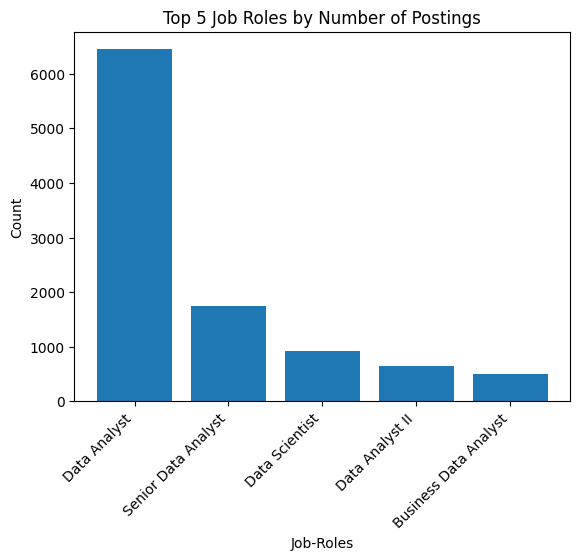

In [17]:
top5roles=df['title'].value_counts().head()
roles_title=top5roles.index.tolist()
roles_count=top5roles.tolist()
plt.bar(roles_title,roles_count)
plt.title("Top 5 Job Roles by Number of Postings")
plt.xticks(rotation=45, ha='right')
plt.xlabel('Job-Roles')
plt.ylabel('Count')
plt.show()

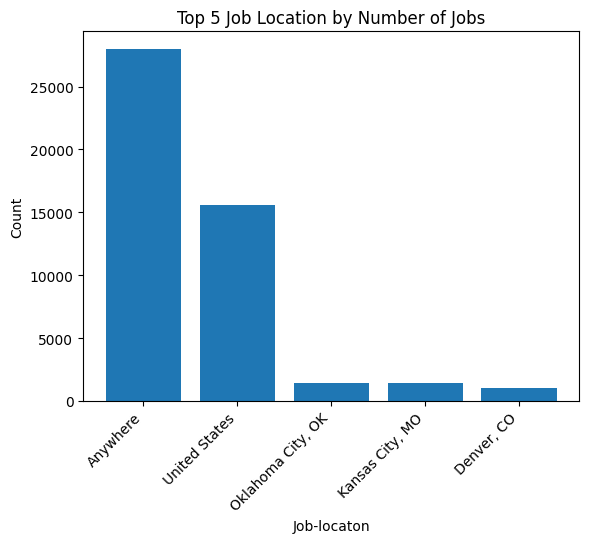

In [18]:
top5location=df['location'].str.strip().value_counts().head()
location_title=top5location.index.tolist()
location_count=top5location.tolist()
plt.bar(location_title,location_count)
plt.title("Top 5 Job Location by Number of Jobs")
plt.xticks(rotation=45, ha='right')
plt.xlabel('Job-locaton')
plt.ylabel('Count')
plt.show()

AttributeError: 'SeriesGroupBy' object has no attribute 'plt'

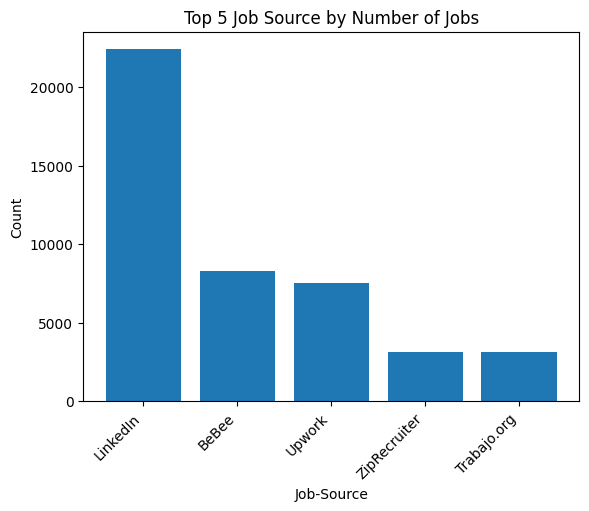

In [22]:
top5job_source=df['via'].str.strip().str.replace(r'^via\s+', '', regex=True).value_counts().head()
top5job_source_title=top5job_source.index.tolist()
top5job_source_count=top5job_source.tolist()
plt.bar(top5job_source_title,top5job_source_count)
plt.title("Top 5 Job Source by Number of Jobs")
plt.xticks(rotation=45, ha='right')
plt.xlabel('Job-Source')
plt.ylabel('Count')
df.groupby('title')['salary_yearly'].plt.show()

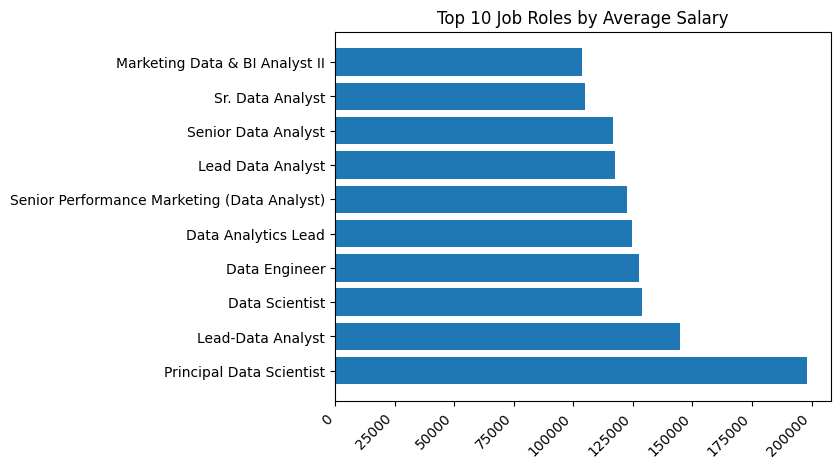

In [21]:
salary_by_role = (
    df.groupby('title')['salary_yearly']
      .agg(['mean', 'count'])
)

salary_by_role = salary_by_role[salary_by_role['count'] >= 10]

salary_by_role = salary_by_role.sort_values(
    'mean', ascending=False
).head(10)

salary_by_role


salary_by_role_title=salary_by_role.index.tolist()
salary_by_role_count=salary_by_role['mean'].tolist()
plt.barh(salary_by_role_title,salary_by_role_count)
plt.title("Top 10 Job Roles by Average Salary")
plt.xticks(rotation=45, ha='right')
plt.show()

In [23]:
df['Posted_Month'].value_counts().sort_index()

,count
Posted_Month,
1.0,8006
2.0,7230
3.0,6474
4.0,5067
5.0,4120
6.0,3969
7.0,4002
8.0,3041
9.0,3507


In [24]:
# Converts 1, 2, 4 to actual dates, then extracts the 3-letter month name ('Jan', 'Feb', 'Apr')
df['month_name'] = pd.to_datetime(df['Posted_Month'], format='%m').dt.strftime('%b')

In [25]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)
df['month_name'].value_counts().sort_index()


,count
month_name,
Jan,8006
Feb,7230
Mar,6474
Apr,5067
May,4120
Jun,3969
Jul,4002
Aug,3041
Sep,3507


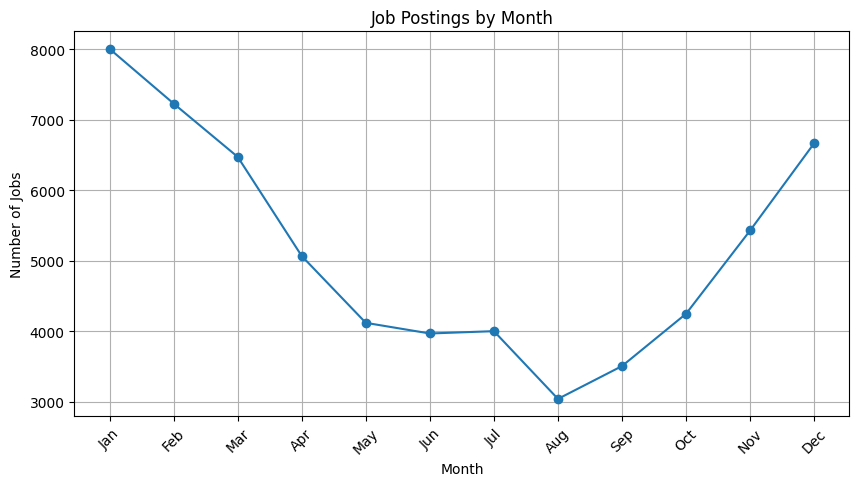

In [26]:
Month_name_title = df['month_name'].value_counts().sort_index().index
Month_name_count = df['month_name'].value_counts().sort_index().values

plt.figure(figsize=(10, 5))
plt.plot(Month_name_title, Month_name_count, marker='o')

plt.title("Job Postings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

#KEY INSIGHTS

1.Data Analyst is the most frequently occurring job role in the dataset, with the highest number of job postings.

2."Anywhere" is the most common job location, indicating that many postings are not restricted to a specific location.

3.Power BI, Python, SQL, Azure, and DAX are among the skills associated with the data-analyst roles you investigated.

4.Quantitative Researcher – Fundamental Equities has the highest salary_avg of $550,000, but this result is based on only one posting, so it should be interpreted cautiously.

5.Full-time is the most common schedule type, with 45,082 postings.

6.Contractor and temporary/contract work are also present in the job market, showing that opportunities are not limited to full-time positions.

7.LinkedIn is the leading job-posting source in the dataset, followed by other major sources such as BeBee and Upwork.

8.Upwork has the highest number of job postings among companies/platforms listed in company_name, with 7,533 postings.

9.Job postings are relatively high from January through April, with January having the highest monthly count.

10.August represents the lowest point in monthly job postings, after which postings increase from September and reach a relatively high level again in December.